# **Individual Assignment 1: Translating the Lecture 01 R Workflow into Python**

This notebook reproduces the COMPAS recidivism analysis originally implemented in R. The purpose is to recreate the full workflow in Python, including data cleaning, exploratory analysis, logistic regression, and fairness diagnostics.

In [1]:
#Imports
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix

## Load the COMPAS Dataset

The first step is to load the COMPAS recidivism dataset from the ProPublica repository and inspect its structure. The original dataset contains 7,214 defendants.

In [2]:
# Load the COMPAS dataset

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

raw_data = pd.read_csv(url)

# Equivalent of nrow(raw_data)
print(len(raw_data))

7214


In [3]:
# Equivalent of head(raw_data, 10)
print(raw_data.head(10))

   id                name      first         last compas_screening_date  \
0   1    miguel hernandez     miguel    hernandez            2013-08-14   
1   3         kevon dixon      kevon        dixon            2013-01-27   
2   4            ed philo         ed        philo            2013-04-14   
3   5         marcu brown      marcu        brown            2013-01-13   
4   6  bouthy pierrelouis     bouthy  pierrelouis            2013-03-26   
5   7        marsha miles     marsha        miles            2013-11-30   
6   8       edward riddle     edward       riddle            2014-02-19   
7   9      steven stewart     steven      stewart            2013-08-30   
8  10    elizabeth thieme  elizabeth       thieme            2014-03-16   
9  13           bo bradac         bo       bradac            2013-11-04   

      sex         dob  age          age_cat              race  ...  \
0    Male  1947-04-18   69  Greater than 45             Other  ...   
1    Male  1982-01-22   34        

## Select Variables and Applying the filters

The original R workflow uses only the variables needed for the analysis. The data are filtered to remove:

- observations where the COMPAS screening occurred more than 30 days from arrest
- observations with missing recidivism information
- ordinary traffic charges
- observations with missing COMPAS scores

After filtering, the final analytical sample contains 6,172 defendants.

## Convert Variables to the Appropriate Data Types

The jail entry and exit variables are converted to datetime format. Categorical variables are converted to factors

- Reference race: Caucasian
- Reference age category: 25–45
- Reference sex: Male
- Reference charge degree: Felony


In [4]:
# ------------------------------------------------------------
# Numeric and Datetime Variables
# ------------------------------------------------------------

numeric_vars = [
    "age",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score"
]

datetime_vars = [
    "c_jail_in",
    "c_jail_out"
]

# ------------------------------------------------------------
# Select only required columns
# ------------------------------------------------------------

df = raw_data[
    [
        "age",
        "c_charge_degree",
        "race",
        "age_cat",
        "score_text",
        "sex",
        "priors_count",
        "days_b_screening_arrest",
        "decile_score",
        "is_recid",
        "two_year_recid",
        "c_jail_in",
        "c_jail_out"
    ]
].copy()

# ------------------------------------------------------------
# Filtering
# ------------------------------------------------------------

df = df[
    (df["days_b_screening_arrest"] >= -30) &
    (df["days_b_screening_arrest"] <= 30)
]

df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# ------------------------------------------------------------
# Type conversions
# ------------------------------------------------------------

for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], errors="coerce")

for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# ------------------------------------------------------------
# Derived factors
# ------------------------------------------------------------

df["crime_factor"] = pd.Categorical(df["c_charge_degree"])

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=[
        "25 - 45",
        "Greater than 45",
        "Less than 25"
    ]
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=[
        "Caucasian",
        "African-American",
        "Asian",
        "Hispanic",
        "Native American",
        "Other"
    ]
)

df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"]
)

df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] == "Low", "LowScore", "HighScore"),
    categories=["LowScore", "HighScore"]
)

# Equivalent of nrow(df)
print(len(df))

6172


## Inspect the Cleaned Dataset

The following output confirms the structure of the cleaned dataset, including variable names, data types, and the number of observations remaining after preprocessing.

In [5]:
# Equivalent of head(df)
print(df.head())

   age c_charge_degree              race          age_cat score_text   sex  \
0   69               F             Other  Greater than 45        Low  Male   
1   34               F  African-American          25 - 45        Low  Male   
2   24               F  African-American     Less than 25        Low  Male   
5   44               M             Other          25 - 45        Low  Male   
6   41               F         Caucasian          25 - 45     Medium  Male   

   priors_count  days_b_screening_arrest  decile_score is_recid  \
0             0                     -1.0             1        0   
1             0                     -1.0             3        1   
2             4                     -1.0             4        1   
5             0                      0.0             1        0   
6            14                     -1.0             6        1   

  two_year_recid           c_jail_in          c_jail_out crime_factor  \
0              0 2013-08-13 06:03:42 2013-08-14 05:41:2

In [6]:
# Equivalent of glimpse(df)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   category      
 2   race                     6172 non-null   category      
 3   age_cat                  6172 non-null   category      
 4   score_text               6172 non-null   category      
 5   sex                      6172 non-null   category      
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   category      
 10  two_year_recid           6172 non-null   category      
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

Higher COMPAS scores are slightly correlated with a longer length of stay.

## Relationship Between Jail Stay Length and COMPAS Score

The notebook calculates the number of days each defendant spent in jail and compares it with the COMPAS decile score.

A positive correlation would indicate that defendants assigned higher COMPAS scores also tend to remain in jail longer.

In [7]:
# Length of stay correlation

df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() -
    df["c_jail_in"].dt.normalize()
).dt.days

print(df["length_of_stay"].corr(df["decile_score"]))

0.2073296916147045


The correlation between jail stay length and COMPAS decile score is approximately 0.21. This indicates a weak positive relationship: defendants with higher COMPAS scores tend to spend slightly longer in jail.

## Exploratory Data Analysis

This section summarizes the demographic structure of the filtered dataset, including age groups, race, sex, COMPAS risk scores, and recidivism outcomes.

In [8]:
print(df["age_cat"].value_counts())

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64


In [9]:
print(df["race"].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [10]:
print(f"Black defendants: {3175 / 6172 * 100:.2f}%")
print(f"White defendants: {2103 / 6172 * 100:.2f}%")
print(f"Hispanic defendants: {509 / 6172 * 100:.2f}%")
print(f"Asian defendants: {31 / 6172 * 100:.2f}%")
print(f"Native American defendants: {11 / 6172 * 100:.2f}%")

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


The filtered sample is predominantly African-American and Caucasian. African-American defendants account for approximately 51% of the sample, while Caucasian defendants account for approximately 34%.


In [11]:

print(df["score_text"].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [12]:
print(pd.crosstab(df["sex"], df["race"]))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [13]:
print(df["sex"].value_counts())

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [14]:
print(f"Men: {4997 / 6172 * 100:.2f}%")
print(f"Women: {1175 / 6172 * 100:.2f}%")

Men: 80.96%
Women: 19.04%


Men make up roughly 81% of the sample. Approximately 45% of defendants recidivated within two years.

In [15]:
print((df["two_year_recid"] == 1).sum())

2809


In [16]:

print((df["two_year_recid"] == 1).sum() / len(df) * 100)

45.51198963058976


## Compare COMPAS Decile Scores by Race

The following histograms compare the distribution of COMPAS decile scores for African-American and Caucasian defendants.

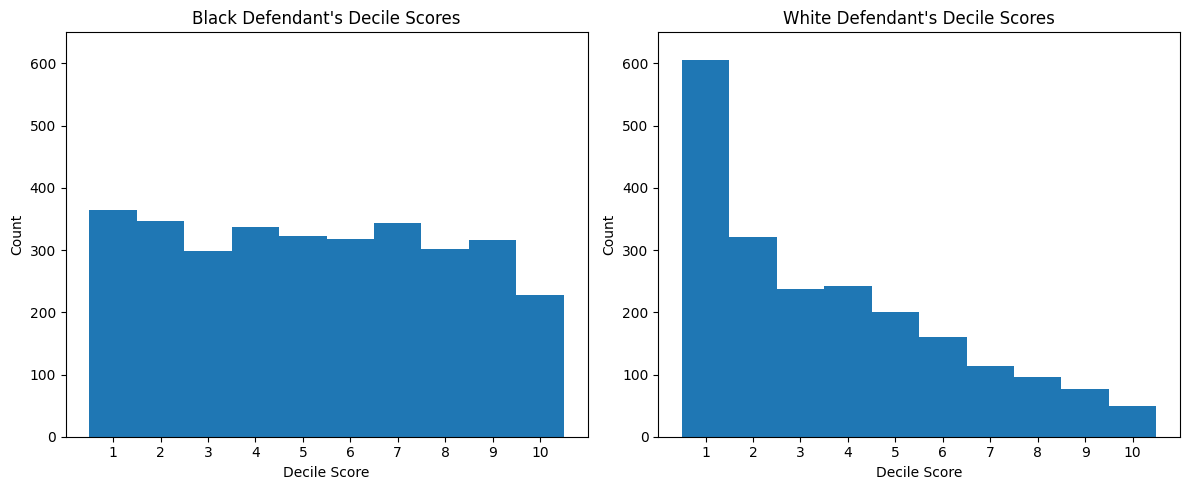

In [17]:
# Histogram of decile scores by race

black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(
    black_df["decile_score"],
    bins=np.arange(1, 12) - 0.5
)
ax[0].set_title("Black Defendant's Decile Scores")
ax[0].set_xlabel("Decile Score")
ax[0].set_ylabel("Count")
ax[0].set_xticks(range(1, 11))
ax[0].set_ylim(0, 650)

ax[1].hist(
    white_df["decile_score"],
    bins=np.arange(1, 12) - 0.5
)
ax[1].set_title("White Defendant's Decile Scores")
ax[1].set_xlabel("Decile Score")
ax[1].set_ylabel("Count")
ax[1].set_xticks(range(1, 11))
ax[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

African-American defendants are more concentrated in the higher COMPAS decile score categories, while Caucasian defendants are more concentrated in the lower categories.

In [18]:
# Equivalent of xtabs(~ decile_score + race, data=df)
print(pd.crosstab(df["decile_score"], df["race"]))

# Convert score_factor to binary for logistic regression
# LowScore = 0, HighScore = 1
df["score_binary"] = np.where(df["score_factor"] == "HighScore", 1, 0)

race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other  
decile_score         
1      

## Logistic Regression Model

The logistic regression model predicts whether a defendant receives a medium/high COMPAS score rather than a low COMPAS score.

The model includes:

- sex
- age category
- race
- number of prior arrests
- charge severity
- two-year recidivism status

In [19]:
# Logistic regression
model_glm = smf.logit(
    formula="""
    score_binary ~
    C(gender_factor, Treatment(reference='Male')) +
    C(age_factor, Treatment(reference='25 - 45')) +
    C(race_factor, Treatment(reference='Caucasian')) +
    priors_count +
    C(crime_factor, Treatment(reference='F')) +
    two_year_recid
    """,
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        15:23:13   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------

The logistic regression results show that the strongest predictors of receiving a higher COMPAS score are:

- being younger than 25
- having more prior arrests
- recidivating within two years
- being African-American rather than Caucasian

The coefficient for African-American defendants is positive and statistically significant, indicating that African-American defendants are more likely than otherwise similar Caucasian defendants to receive a higher COMPAS score.

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime,
previous arrests, and future criminal behavior.

In [20]:
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

black_effect = np.exp(0.47721) / (
    1 - control + control * np.exp(0.47721)
)

Women are 19.4% more likely than men to get a higher score.

In [21]:

female_effect = np.exp(0.22127) / (
    1 - control + control * np.exp(0.22127)
)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [22]:
young_effect = np.exp(1.30839) / (
    1 - control + control * np.exp(1.30839)
)

## Interpreting the Regression Coefficients

To make the coefficients easier to interpret, selected coefficients are converted into multiplicative effects on the probability of receiving a high-risk score.

In [23]:
print("Black defendants relative effect:", black_effect)
print("Women relative effect:", female_effect)
print("Under 25 relative effect:", young_effect)

# Predicted probabilities and predicted classes
df["pred_prob"] = model_glm.predict(df)

df["pred_class"] = np.where(
    df["pred_prob"] >= 0.5,
    "Recid",
    "No Recid"
)

Black defendants relative effect: 1.4528408658138932
Women relative effect: 1.1947978508506671
Under 25 relative effect: 2.4961202077189455


Relative to otherwise similar defendants:

- African-American defendants are substantially more likely to receive a higher COMPAS score.
- Women are slightly more likely to receive a higher COMPAS score than men.
- Defendants younger than 25 experience the largest increase in predicted risk.

## Model Performance

The notebook evaluates the logistic regression model using a confusion matrix and standard classification metrics.

In [24]:
# Overall confusion matrix

actual = df["two_year_recid"].astype(int)
pred = np.where(df["pred_class"] == "Recid", 1, 0)

cm = confusion_matrix(actual, pred)

TN, FP, FN, TP = cm.ravel()

print("\nOverall Confusion Matrix")
print(cm)

print(f"Accuracy  : {(TP + TN) / (TP + TN + FP + FN):.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


Overall Confusion Matrix
[[2653  710]
 [ 945 1864]]
Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


The model achieves approximately:

- Accuracy: 0.73
- Precision: 0.72
- Recall: 0.66
- False-positive rate: 0.21
- False-negative rate: 0.34

These values are very similar to those produced in the original R script.

## Evaluate Performance Separately by Race

To assess fairness, the notebook computes confusion matrices and error rates separately for each racial group.

In [25]:
# Confusion matrix by race

results = []

for race, group in df.groupby("race"):

    actual = group["two_year_recid"].astype(int)
    pred = np.where(group["pred_class"] == "Recid", 1, 0)

    cm = confusion_matrix(actual, pred, labels=[0, 1])

    TN, FP, FN, TP = cm.ravel()

    results.append({
        "race": race,
        "n": len(group),
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": round((TP + TN) / len(group), 3),
        "Precision": round(TP / (TP + FP), 3) if (TP + FP) > 0 else np.nan,
        "Recall": round(TP / (TP + FN), 3) if (TP + FN) > 0 else np.nan,
        "FPR": round(FP / (FP + TN), 3) if (FP + TN) > 0 else np.nan,
        "FNR": round(FN / (FN + TP), 3) if (FN + TP) > 0 else np.nan
    })

race_metrics = pd.DataFrame(results).sort_values("n", ascending=False)

print("\nConfusion Matrix by Race")
print(race_metrics)


Confusion Matrix by Race
               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


African-American defendants experience higher false-positive rates than Caucasian defendants, while Caucasian defendants experience higher false-negative rates. This reproduces the central fairness tradeoff identified in the COMPAS literature.

## Racial Disparity in Error Rates

The disparity analysis compares each racial group with Caucasian defendants, who serve as the reference group.

In [26]:
# FPR and FNR disparity relative to Caucasian defendants

white_fpr = race_metrics.loc[
    race_metrics["race"] == "Caucasian", "FPR"
].values[0]

white_fnr = race_metrics.loc[
    race_metrics["race"] == "Caucasian", "FNR"
].values[0]

race_metrics["delta_FPR"] = (
    race_metrics["FPR"] - white_fpr
).round(3)

race_metrics["delta_FNR"] = (
    race_metrics["FNR"] - white_fnr
).round(3)

print("\nFPR and FNR Disparity by Race")
print(
    race_metrics[
        ["race", "n", "FPR", "FNR", "delta_FPR", "delta_FNR"]
    ]
)


FPR and FNR Disparity by Race
               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


## Racial Disparity in Error Rates

The results show that African-American defendants have a substantially higher false-positive rate than Caucasian defendants. At the same time, Caucasian defendants are more likely to be incorrectly classified as low risk when they later recidivate.

This pattern illustrates the tradeoff between different fairness criteria and highlights why COMPAS has been widely debated in the literature.